In [7]:
# first things first - importing all the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("all libraries imported successfully!")

all libraries imported successfully!


In [9]:
import zipfile
import os

zip_file_path = '/content/IMDb Movies India.csv (1).zip'
extracted_csv_name = 'IMDb Movies India.csv'
extracted_path = './' # Extract to current directory

# Check if the zip file exists and extract it
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
    print(f"'{extracted_csv_name}' extracted from '{zip_file_path}'")
else:
    print(f"Zip file not found at {zip_file_path}. Please ensure it's downloaded.")

# loading the dataset
df = pd.read_csv(extracted_csv_name, encoding='latin1')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

'IMDb Movies India.csv' extracted from '/content/IMDb Movies India.csv (1).zip'
Dataset loaded successfully!
Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [11]:
# checking the basic info
print("Shape of dataset:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape of dataset: (15509, 10)

Column Names: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Missing Values:
 Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

Basic Statistics:


,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [12]:
# dropping rows where Rating is missing
df = df.dropna(subset=['Rating'])

# cleaning Year column
df['Year'] = df['Year'].astype(str).str.extract('(\d+)').astype(float)

# cleaning Duration column
df['Duration'] = df['Duration'].astype(str).str.extract('(\d+)').astype(float)

# cleaning Votes column
df['Votes'] = df['Votes'].astype(str).str.replace(',', '').str.extract('(\d+)').astype(float)

# filling missing values
df['Duration'].fillna(df['Duration'].median(), inplace=True)
df['Votes'].fillna(df['Votes'].median(), inplace=True)
df['Genre'].fillna('Unknown', inplace=True)
df['Director'].fillna('Unknown', inplace=True)
df['Actor 1'].fillna('Unknown', inplace=True)
df['Actor 2'].fillna('Unknown', inplace=True)
df['Actor 3'].fillna('Unknown', inplace=True)

print("Data cleaned successfully!")
print("Remaining shape:", df.shape)

Data cleaned successfully!
Remaining shape: (7919, 10)


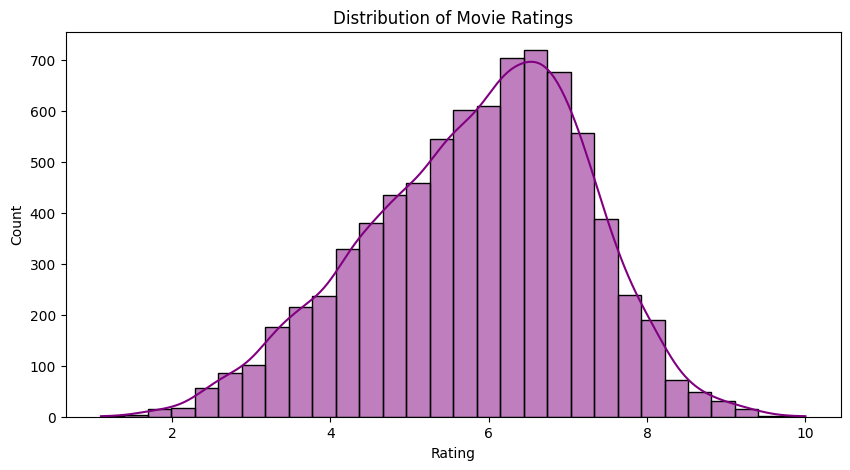

In [13]:
# distribution of movie ratings
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=30, color='purple', kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

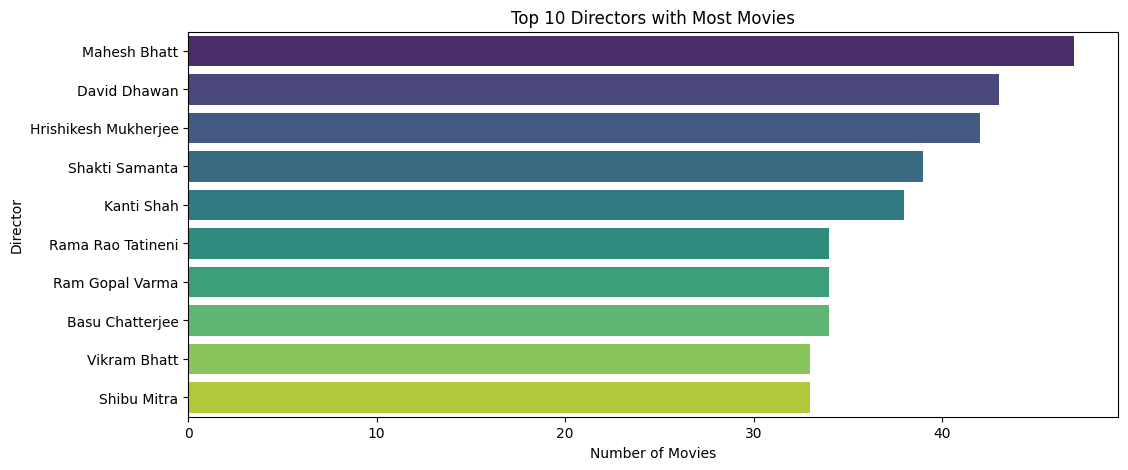

In [15]:
# top 10 directors with most movies
plt.figure(figsize=(12, 5))
top_directors = df['Director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')
plt.title('Top 10 Directors with Most Movies')
plt.xlabel('Number of Movies')
plt.show()

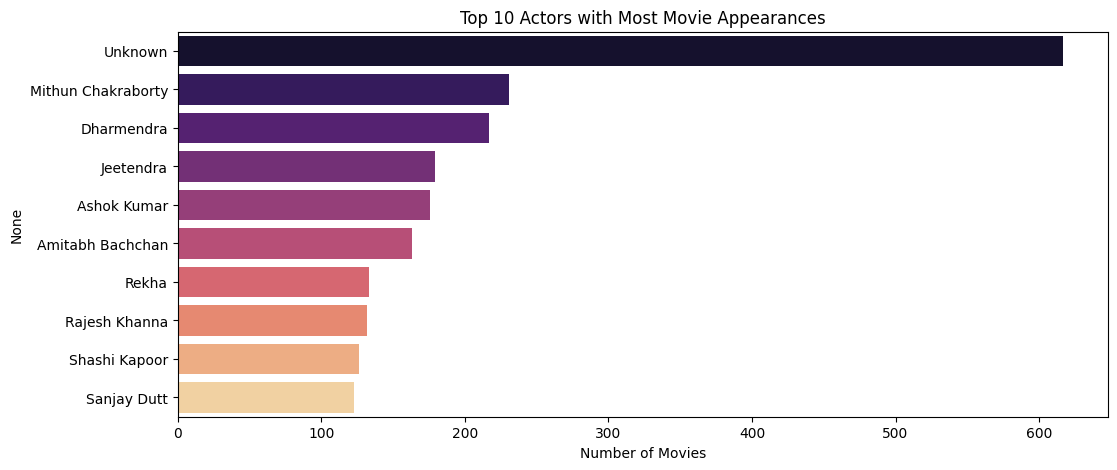

In [16]:
# top 10 actors with most appearances
plt.figure(figsize=(12, 5))
all_actors = pd.concat([df['Actor 1'], df['Actor 2'], df['Actor 3']])
top_actors = all_actors.value_counts().head(10)
sns.barplot(x=top_actors.values, y=top_actors.index, palette='magma')
plt.title('Top 10 Actors with Most Movie Appearances')
plt.xlabel('Number of Movies')
plt.show()

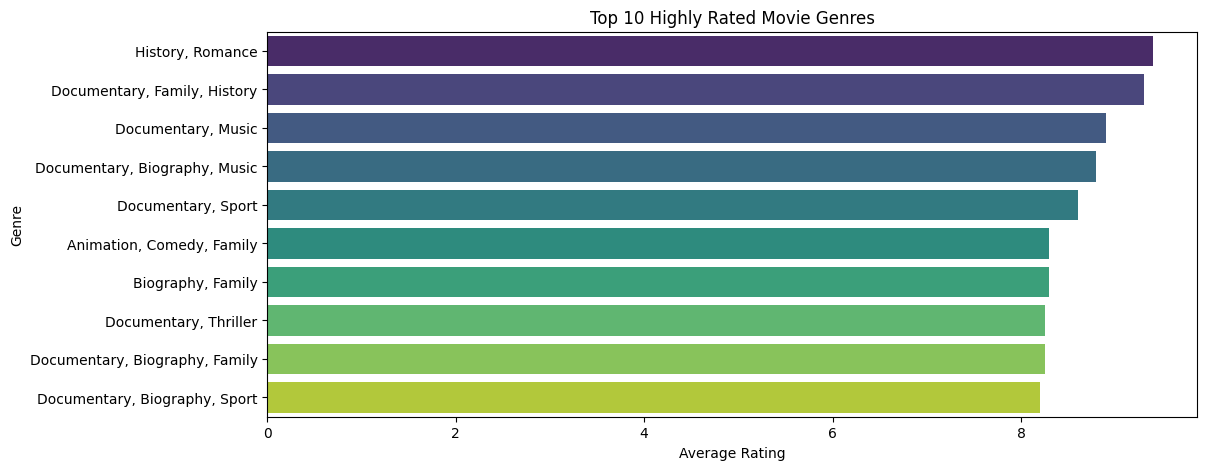

In [17]:
# top 10 genres with highest ratings
plt.figure(figsize=(12, 5))
top_genres = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Highly Rated Movie Genres')
plt.xlabel('Average Rating')
plt.show()

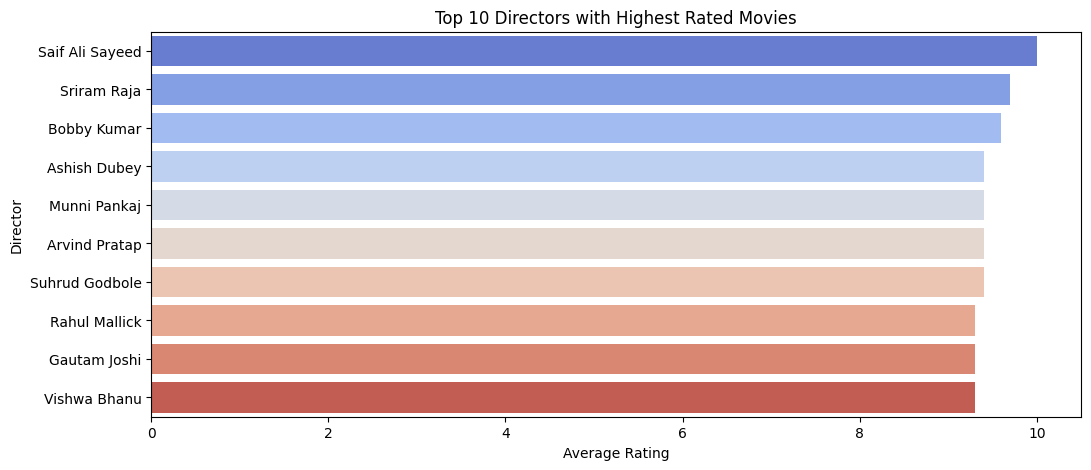

In [18]:
# top 10 directors with highest rated movies
plt.figure(figsize=(12, 5))
top_rated_directors = df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_rated_directors.values, y=top_rated_directors.index, palette='coolwarm')
plt.title('Top 10 Directors with Highest Rated Movies')
plt.xlabel('Average Rating')
plt.show()

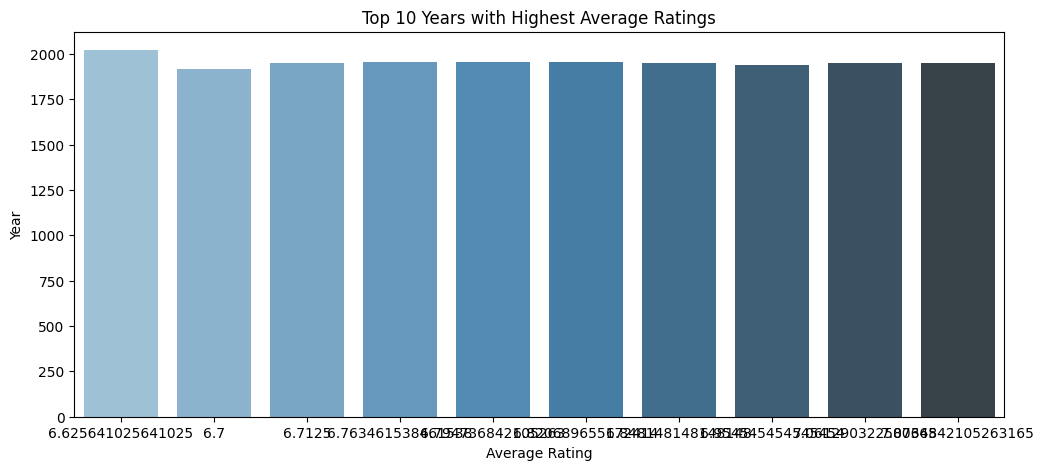

In [19]:
# top 10 years with highest average ratings
plt.figure(figsize=(12, 5))
top_years = df.groupby('Year')['Rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_years.values, y=top_years.index, palette='Blues_d')
plt.title('Top 10 Years with Highest Average Ratings')
plt.xlabel('Average Rating')
plt.show()

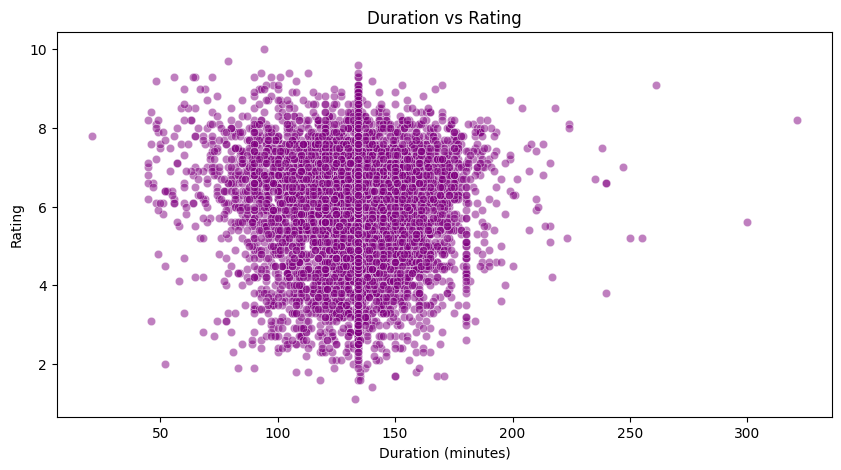

In [20]:
# duration vs rating scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Duration'], y=df['Rating'], alpha=0.5, color='purple')
plt.title('Duration vs Rating')
plt.xlabel('Duration (minutes)')
plt.ylabel('Rating')
plt.show()

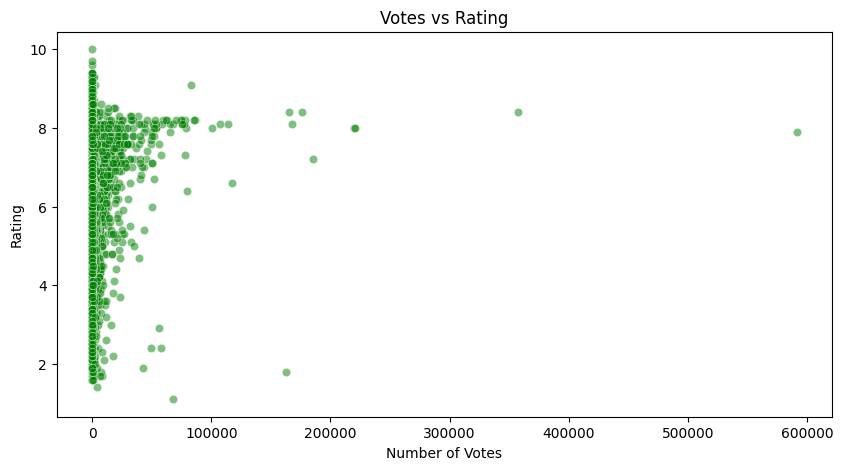

In [21]:
# votes vs rating
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Votes'], y=df['Rating'], alpha=0.5, color='green')
plt.title('Votes vs Rating')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.show()

In [22]:
le = LabelEncoder()

df['Genre_encoded'] = le.fit_transform(df['Genre'].astype(str))
df['Director_encoded'] = le.fit_transform(df['Director'].astype(str))
df['Actor1_encoded'] = le.fit_transform(df['Actor 1'].astype(str))
df['Actor2_encoded'] = le.fit_transform(df['Actor 2'].astype(str))
df['Actor3_encoded'] = le.fit_transform(df['Actor 3'].astype(str))

print("Feature encoding done!")

Feature encoding done!


In [24]:
features = ['Year', 'Duration', 'Votes', 'Genre_encoded',
            'Director_encoded', 'Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded']
target = 'Rating'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nFeatures used for prediction: {features}")
print(f"\nTarget variable: {target}")
print(f"\nTraining data sample:")
X_train.head()

Total samples: 7919
Training samples: 6335
Testing samples: 1584

Features used for prediction: ['Year', 'Duration', 'Votes', 'Genre_encoded', 'Director_encoded', 'Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded']

Target variable: Rating

Training data sample:


,Year,Duration,Votes,Genre_encoded,Director_encoded,Actor1_encoded,Actor2_encoded,Actor3_encoded
8157,2019.0,74.0,10.0,171,2287,1861,2055,647
8455,1981.0,134.0,16.0,268,2616,2082,1732,203
14490,2017.0,136.0,17774.0,337,1192,1939,2447,1746
2697,2003.0,117.0,17.0,0,824,1687,1401,726
15470,1988.0,120.0,33.0,248,2438,1067,173,388


In [25]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("=== Linear Regression Results ===")
print(f"Mean Squared Error: {lr_mse:.2f}")
print(f"R² Score: {lr_r2:.2f}")
print(f"\nSample Predictions vs Actual:")
results_lr = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': lr_pred[:10].round(1)})
print(results_lr.to_string(index=False))

=== Linear Regression Results ===
Mean Squared Error: 1.67
R² Score: 0.10

Sample Predictions vs Actual:
 Actual  Predicted
    3.3        5.9
    5.3        5.5
    5.7        5.2
    7.2        5.8
    3.5        5.8
    7.2        5.5
    3.8        6.1
    6.9        5.8
    5.2        6.1
    7.4        5.9


In [26]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=== Random Forest Results ===")
print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R² Score: {rf_r2:.2f}")
print(f"\nSample Predictions vs Actual:")
results_rf = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': rf_pred[:10].round(1)})
print(results_rf.to_string(index=False))

=== Random Forest Results ===
Mean Squared Error: 1.21
R² Score: 0.35

Sample Predictions vs Actual:
 Actual  Predicted
    3.3        4.4
    5.3        5.1
    5.7        4.9
    7.2        5.7
    3.5        5.3
    7.2        6.0
    3.8        5.6
    6.9        7.0
    5.2        5.5
    7.4        5.9


In [27]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("=== Gradient Boosting Results ===")
print(f"Mean Squared Error: {gb_mse:.2f}")
print(f"R² Score: {gb_r2:.2f}")
print(f"\nSample Predictions vs Actual:")
results_gb = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': gb_pred[:10].round(1)})
print(results_gb.to_string(index=False))

=== Gradient Boosting Results ===
Mean Squared Error: 1.18
R² Score: 0.37

Sample Predictions vs Actual:
 Actual  Predicted
    3.3        4.4
    5.3        5.0
    5.7        5.3
    7.2        5.4
    3.5        5.0
    7.2        5.4
    3.8        5.9
    6.9        6.8
    5.2        5.9
    7.4        6.0


=== Model Comparison ===
            Model  MSE  R² Score
Linear Regression 1.67      0.10
    Random Forest 1.21      0.35
Gradient Boosting 1.18      0.37

Best Model: Gradient Boosting
Best R² Score: 0.37


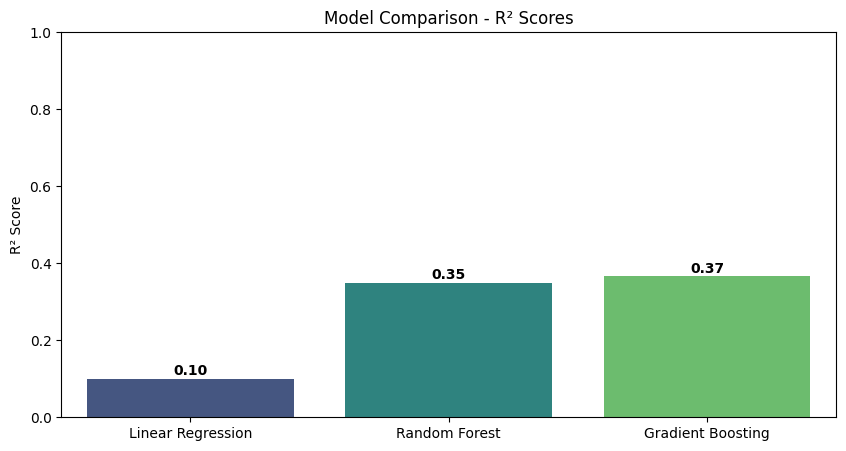

In [29]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
mse_scores = [lr_mse, rf_mse, gb_mse]
r2_scores = [lr_r2, rf_r2, gb_r2]

comparison_df = pd.DataFrame({
    'Model': models,
    'MSE': [round(x, 2) for x in mse_scores],
    'R² Score': [round(x, 2) for x in r2_scores]
})

print("=== Model Comparison ===")
print(comparison_df.to_string(index=False))
print(f"\nBest Model: {models[r2_scores.index(max(r2_scores))]}")
print(f"Best R² Score: {max(r2_scores):.2f}")

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=r2_scores, palette='viridis')
plt.title('Model Comparison - R² Scores')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()

=== Feature Importance ===
         Feature  Importance Score
           Votes          0.214849
            Year          0.197783
   Genre_encoded          0.123458
  Actor3_encoded          0.095717
  Actor2_encoded          0.095036
  Actor1_encoded          0.094654
        Duration          0.092992
Director_encoded          0.085511


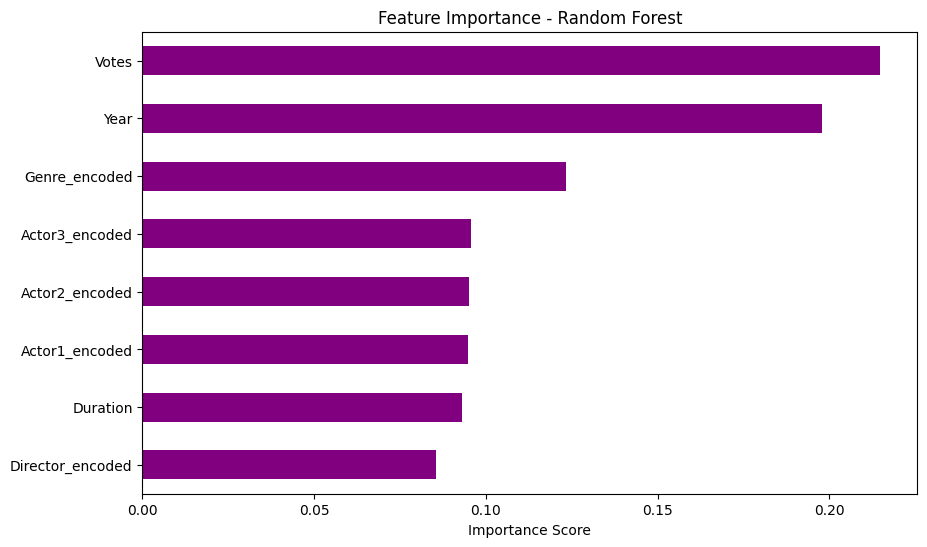

In [30]:
importance = pd.Series(rf_model.feature_importances_, index=features)
importance_df = importance.sort_values(ascending=False).reset_index()
importance_df.columns = ['Feature', 'Importance Score']

print("=== Feature Importance ===")
print(importance_df.to_string(index=False))

importance.sort_values().plot(kind='barh', color='purple', figsize=(10, 6))
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

=== Actual vs Predicted Ratings (Random Forest) ===
 Actual Rating  Predicted Rating  Difference
           3.3               4.4         1.1
           5.3               5.1         0.2
           5.7               4.9         0.8
           7.2               5.7         1.5
           3.5               5.3         1.8
           7.2               6.0         1.2
           3.8               5.6         1.8
           6.9               7.0         0.1
           5.2               5.5         0.3
           7.4               5.9         1.5
           4.3               6.3         2.0
           7.2               6.8         0.4
           5.6               4.8         0.8
           3.9               4.7         0.8
           3.2               4.7         1.5


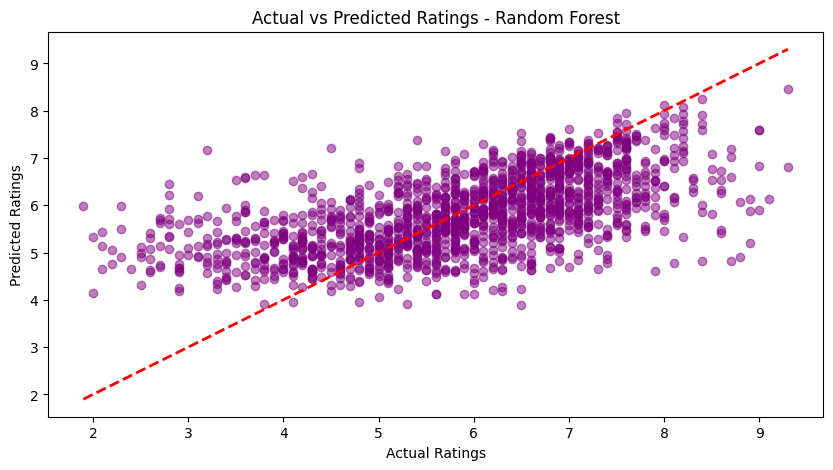

In [31]:
print("=== Actual vs Predicted Ratings (Random Forest) ===")
final_results = pd.DataFrame({
    'Actual Rating': y_test.values[:15],
    'Predicted Rating': rf_pred[:15].round(1),
    'Difference': abs(y_test.values[:15] - rf_pred[:15]).round(1)
})
print(final_results.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.scatter(y_test, rf_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings - Random Forest')
plt.show()

In [32]:
import pickle
pickle.dump(rf_model, open('movie_rating_model.pkl', 'wb'))

print("=== Model Saved Successfully ===")
print("File: movie_rating_model.pkl")
print("Model type: Random Forest Regressor")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Final R² Score: {rf_r2:.2f}")

=== Model Saved Successfully ===
File: movie_rating_model.pkl
Model type: Random Forest Regressor
Number of trees: 100
Final R² Score: 0.35


In [33]:
new_movie = pd.DataFrame({
    'Year': [2023],
    'Duration': [120],
    'Votes': [50000],
    'Genre_encoded': [5],
    'Director_encoded': [10],
    'Actor1_encoded': [20],
    'Actor2_encoded': [15],
    'Actor3_encoded': [8]
})

predicted_rating = rf_model.predict(new_movie)

print("=== New Movie Rating Prediction ===")
print(f"Year: 2023")
print(f"Duration: 120 minutes")
print(f"Votes: 50,000")
print(f"\nPredicted Rating: {predicted_rating[0]:.1f} / 10")

=== New Movie Rating Prediction ===
Year: 2023
Duration: 120 minutes
Votes: 50,000

Predicted Rating: 5.1 / 10
